# UPRM Hackathon 2026 - Object Detection using Convolutional Neural Networks

**Author:** Hamzah Abdulrazzaq, Chelsea Cantone, Erika Hall, Edgar Perez

**Date:** September 25-27, 2026

**Objective:** UPRM Hackathon 2026 will be focused on exploring the capabilities of Convolutional Neural Networks (CNNs) in tackling complex object detection tasks. Specifically, participants will delve into the realm of single-class object detection using the 'Remondis Contamination Dataset' (RCD), which comprises truck-mounted waste camera imagery captured in real-world waste management operations. The dataset includes KITTI-format annotated images featuring plastic_bag instances of varying sizes, occlusion levels, lighting conditions, and background clutter, with bounding-box labels marking each target object. The task at hand is to design and optimize CNN-based detection architectures to accurately localize and classify plastic bags within a given image. The challenge lies in developing a robust model that can effectively handle the complexities of bounding-box regression combined with classification, requiring meticulous attention to data preprocessing, hyper-parameter tuning, and potentially incorporating techniques such as transfer learning, data augmentation, anchor tuning, and ensemble methods. The winning submissions will be evaluated based on their performance, with a key metric being the model's ability to achieve high mean Average Precision at IoU 0.50 (mAP@50) on the validation split, balancing precision and recall across detected instances.

## Table of Contents
1. [Background Information](#1-background-information)
    - [1.1. Convolutional Neural Networks](#11-convolutional-neural-networks)
    - [1.2. Object Detection vs Image Classification (Multi-label)](#12-object-detection-vs-image-classification-multi-label)
    - [1.3 An Example Use Case of Object Detection for Lockheed Martin](#13-an-example-use-case-of-object-detection-for-lockheed-martin)
    - [1.4 Key Terms](#14-key-terms)
    - [1.5 Helpful Resources](#15-helpful-resources)
2. [Setup](#2-setup)
    - [2.1. Download Data](#21-download-data)
    - [2.2 Importing Necessary Libraries](#22-importing-necessary-libraries)
    - [2.3 Custom Image Dataset](#23-custom-image-dataset)
    - [2.4 Image Augmentation](#24-image-augmentation)
3. [Training Loop](#3-training-loop)
    - [3.1 CNN Model Architecture](#31-cnn-model-architecture)
    - [3.2 Model Training](#32-model-training)
4. [Analysis](#4-analysis)
    - [4.1 Visualize Ground Truth vs Predictions](#41-visualize-ground-truth-vs-predictions)
    - [4.2 Performance Analysis (Where is the model underperforming)](#43-performance-analysis-where-is-the-model-underperforming)
5. [Test](#5-test)
    - [5.1 Download Test Data](#51-download-test-data)
    - [5.2 Create Test DataLoader](#51-create-test-dataloader)
    - [5.3 Grade Model on Test Set](#52-grade-model-on-test-set)
6. [Grading/Submission Guidelines](#6-gradingsubmission-guidelines)

## 1. Background Information

### 1.1 Convolutional Neural Networks:

A convolutional neural network (CNN or ConvNet) is a class of deep neural networks, most commonly applied to analyzing visual imagery. They have proven to be very effective in image and video recognition, recommender systems, image classification, medical image analysis, natural language processing, brain-computer interfaces, and financial time series modeling. CNNs are regularized versions of multilayer perceptrons. Multilayer perceptrons usually mean fully connected networks, that is, each neuron in one layer is connected to all neurons in the next layer. The "fully-connectedness" of these networks makes them prone to overfitting data. Typical ways of regularization include adding some form of magnitude measurement of weights to the loss function. CNNs take a different approach towards regularization: they take advantage of the hierarchical pattern in data and assemble more complex patterns using smaller and simpler patterns. Therefore, on the scale of connectedness and complexity, CNNs are on the lower extreme. Convolutional networks were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex. Individual cortical neurons respond to stimuli only in a restricted region of the visual field known as the receptive field. The receptive fields of different neurons partially overlap such that they cover the entire visual field.

### 1.2 Object Detection vs Image Classification (Multi-label)

![choose_computer_vision_arch.png](./img/choose_computer_vision_arch.png)

*[Image Source](https://storage.ghost.io/c/2c/8d/2c8d8c0d-1c15-4b6d-825e-02b78d61d40a/content/images/size/w1000/size/w2000/2020/07/choose_computer_vision_arch.png)*

Object detection vs image classification are two related but different challenges in computer vision. Object detection looks at digital images and videos to locate objects of interest and label them.

| Image Classification (multi-label) | Object Detection |
| :--- | :--- |
| *Questions*: What labels are present in this image? | *Questions*: Is there an object here (objectness)? Where are the objects in the image (localization)? What labels are present (classification)? |
| *Output*: Class probabilities | *Output*: Bounding boxes, class probabilities, confidence scores (objectness) |
| *Evaluation metric*: F1-score | *Evaluation metric*: mAP@50 IoU, mean average precision at 50% Intersection over Union |

For explanation of mAP, see the references section below. mAP@50 indicates the mean Average Precision, where the Intersection over Union threshold is set to 0.5. Practically this means that the overlap of the ground truth bounding box to the predicted bounding box sufficiently overlap.

![Intersection over Union](./img/IoU-graphic.png)

[*Source*](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FrmKLxCtkokDC3Yr1wc70w.png)

### 1.3 An Example Use Case of Object Detection for Lockheed Martin
> GATR (Globally-scalable Automated Target Recognition) is a Lockheed Martin software system for real-time object detection and classification in satellite imagery on a worldwide basis. 
![GATR Object Detection](./img/Screenshot%202026-08-10%20134544.png)

[*Globally-scalable Automated Target Recognition (GATR) 2019*](https://arxiv.org/pdf/2009.04836)

### 1.4 Key Terms:
- **Anchor box** - in some object detection CNN models predefined reference boxes, of fixed size and aspect ratio, are used to localize objects
- **Backbone** - a backbone is a very unspecialized CNN that is inserted into a computer vision model to extract essential visual features from raw images (edges, corners, textures, shapes, etc.) into a feature map. Example backbone are ResNet, CSPNet, or a Vision Transformer.
- **Bounding box (bbox)** - the rectangular frame surrounding an object in an image or video. Our labeled dataset contains ground truth bounding boxes that were annotated by humans. We will compare the bounding boxes generated by our model to the ground truth annotations.
- **Localization** - uses regression to predict four numbers representing bounding box coordinates (center point, width, and height).
- **Objectness** - in computer vision, measure that scores how likely a specific image window contains an actual object rather than background.
- **Non-Maximum Suppression (NMS)** - A post processing technique to remove overlapping bounding boxes of the same objecct. Some computer vision models do not deal with this challenge.


### 1.5 Helpful Resources:

Neural Networks:
- [What are Convolutional Neural Networks](https://www.bing.com/videos/search?q=convolutional+neural+network&docid=603549927117705930&mid=E7ED04059A9474B24BFEE7ED04059A9474B24BFE&view=detail&FORM=VIRE)
- [CNN Explainer - Learn CNN In Your Browser](https://poloclub.github.io/cnn-explainer/)
- [Neural Network Playground](https://playground.tensorflow.org/)
- [Interactive Demo for Image kernels](https://deeplizard.com/resource/pavq7noze2)
- [Introduction to Pooling Layers](https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/)

Object Detection
- [Overview of Object Detection](https://machinelearningmastery.com/object-recognition-with-deep-learning/)
- [Anchor-Based vs Anchor-Free Object Detection](https://www.abhik.ai/concepts/computer-vision/anchor-based-vs-anchor-free)
- [YOLO Object Detection Explained](https://www.datacamp.com/blog/yolo-object-detection-explained)
- [mAP (mean Average Precision) for Object Detection](https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173)

## 2. Setup

### 2.1. Download Data

Unzip your data into the data/ folder so the folder structure looks like:

```
data/
  training/
    image_2/    # *.jpg
    label_2/    # *.txt (KITTI format)
  val/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
```


### 2.2 Importing Necessary Libraries

In [1]:
!pip install -r requirements.txt

In [2]:
import math
import os
import random
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import boxes as box_ops
import torchvision.transforms.functional as TF
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Repository root (assumes the notebook lives in <repo>/event_materials/).
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "event_materials" else Path.cwd()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class id 0 is reserved for background in torchvision detection models.
CLASS_NAME_TO_ID = {"plastic_bag": 1}
NUM_CLASSES = 1 + len(CLASS_NAME_TO_ID)  # background + foreground

print(f"Using device: {DEVICE}")
print(f"NUM_CLASSES (background + foreground): {NUM_CLASSES}")
print(f"Repo root: {REPO_ROOT}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected.")
    

Using device: cuda
NUM_CLASSES (background + foreground): 2
Repo root: /home/sagemaker-user/uprm-hackathon-2026
NVIDIA A10G


In [3]:
if torch.cuda.is_available():
    # Returns bytes; convert to MB
    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    
    print(f"Allocated by PyTorch Tensors: {allocated:.2f} MB")
    print(f"Cached/Reserved by PyTorch:    {reserved:.2f} MB")
    
    # Or print a highly detailed diagnostic summary
    print(torch.cuda.memory_summary(device=0))

Allocated by PyTorch Tensors: 0.00 MB
Cached/Reserved by PyTorch:    0.00 MB
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   | 

In [4]:
import warnings 
warnings.filterwarnings("ignore")

### 2.3 Custom Image Dataset

A PyTorch Custom Image Dataset is a class that inherits from PyTorch's Dataset class which provides a way to create a dataset that is tailored to your requirements and needs. It integrates efficiently with PyTorch's DataLoader, allowing us to load and process images in batches during model training and validation

#### What is it used for?
- Data Loading: Standardized way to load images and labels from disk.
- Data Preprocessing: Consistent application of transformations (resizing, augmentation, etc.) to images.
- Batch Creation: Mini-batch generation for training.
- Memory Efficiency: Load images only when needed rather than storing entire dataset in memory. 

Provided below is a custom image dataset that you may use for this challenge. You may add your own modifications by reading through [PyTorch's documentation](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html). 

In [5]:
# Directory names differ between the two splits (hard-coded on disk).
_SPLIT_DIRS = {
    "train": ("image", "label"),
    "val":   ("image",   "label"),
    "test": ("image", "label")
}


def _parse_kitti_label(label_path: Path) -> Tuple[List[List[float]], List[int]]:
    """Parse a single KITTI-format .txt file into boxes and labels.

    Returns (boxes_xyxy, labels). Boxes with non-positive width/height are dropped.
    Only foreground classes in CLASS_NAME_TO_ID are kept; others are silently ignored.
    """
    boxes: List[List[float]] = []
    labels: List[int] = []
    if not label_path.exists():
        return boxes, labels
    with open(label_path, "r") as f:
        for raw in f:
            parts = raw.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in CLASS_NAME_TO_ID:
                continue
            xmin, ymin, xmax, ymax = (float(parts[4]), float(parts[5]),
                                      float(parts[6]), float(parts[7]))
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_NAME_TO_ID[cls])
    return boxes, labels


class KittiPlasticBagDataset(Dataset):
    """PyTorch Dataset over KITTI-format plastic-bag data (self-contained version)."""

    def __init__(
        self,
        root,
        split: str = "train",
        transforms: Optional[Callable] = None,
    ) -> None:
        if split not in _SPLIT_DIRS:
            raise ValueError(f"split must be one of {list(_SPLIT_DIRS)}, got {split!r}")
        self.split = split
        self.transforms = transforms

        root = Path(root)
        # Accept either the repo `data/` folder or a specific split root.
        if (root / "training").is_dir() and (root / "val").is_dir():
            split_root = root / ("training" if split == "train" else split)
        else:
            split_root = root
        img_dir_name, lbl_dir_name = _SPLIT_DIRS[split]
        self.image_dir = split_root / img_dir_name
        self.label_dir = split_root / lbl_dir_name
        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image dir not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label dir not found: {self.label_dir}")

        stems = sorted(p.stem for p in self.image_dir.glob("*.jpg"))
        self.ids: List[str] = [s for s in stems if (self.label_dir / f"{s}.txt").exists()]
        if not self.ids:
            raise RuntimeError(f"No paired image/label files found under {split_root}")

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]
        img_path = self.image_dir / f"{stem}.jpg"
        lbl_path = self.label_dir / f"{stem}.txt"

        img = Image.open(img_path).convert("RGB")
        boxes, labels = _parse_kitti_label(lbl_path)

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)

        return img, target


def detection_collate_fn(batch):
    """Detection targets are variable-length; keep them as a tuple of dicts."""
    images, targets = list(zip(*batch))
    return list(images), list(targets)


### 2.4 Image Augmentation

Image augmentation is an absolutely wonderful way to artificially expand your training dataset, which is especially valuable when working with limited data — a common constraint in real-world image tasks. By creating variations of existing images through transformations like rotations, flips, zooms, and crops, you essentially teach your CNN to recognize objects under different viewing conditions without collecting additional data.

More fundamentally, augmentation directly addresses overfitting by preventing the network from memorizing exact pixel patterns. When a CNN sees the same exact images repeatedly, it tends to learn specific pixel configurations rather than generalizable features. By presenting slightly different versions each time, you force the network to learn robust representations that capture the essence of objects rather than superficial details.

Augmentation also introduces invariance properties into your model. For classification tasks, whether an image is slightly rotated, zoomed, or shifted shouldn't change the label. By training with these variations, your CNN develops translation, rotation, and scale invariance—crucial properties for real-world deployment where objects rarely appear in perfectly consistent positions or orientations.

The CustomImageDataset created above is setup to handle image transforms. An example is provided below with horizontal flip and color jitter transforms applied. See documentation [here](https://docs.pytorch.org/vision/stable/transforms.html?highlight=compose)


In [6]:
from torchvision.transforms import ColorJitter


class TrainTransforms:
    """Light on-the-fly augmentation for the training split.

    - Random horizontal flip (with box coord update).
    - Photometric color jitter (brightness/contrast/saturation/hue) applied
      to the PIL image before tensor conversion. Reduces train/val
      overconfidence gap without needing to re-map bounding boxes.
    - PIL -> float tensor in [0, 1], CHW.
    """

    def __init__(self, hflip_prob: float = 0.5) -> None:
        self.hflip_prob = float(hflip_prob)
        self.color_jitter = ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05,
        )

    def __call__(self, img: Image.Image, target: dict) -> Tuple[torch.Tensor, dict]:
        if self.hflip_prob > 0 and random.random() < self.hflip_prob:
            w = img.width
            img = TF.hflip(img)
            if target["boxes"].numel() > 0:
                boxes = target["boxes"].clone()
                x1 = w - boxes[:, 2]
                x2 = w - boxes[:, 0]
                boxes[:, 0] = x1
                boxes[:, 2] = x2
                target["boxes"] = boxes

        # Photometric jitter operates purely on pixel intensities; boxes
        # are unchanged, so no target update is needed here.
        img = self.color_jitter(img)

        img_t = TF.to_tensor(img)
        return img_t, target

### 2.6 Datasets and DataLoader

In [7]:
DATA_ROOT = REPO_ROOT / "data"
print("Data root:", DATA_ROOT)

train_ds = KittiPlasticBagDataset(root=DATA_ROOT, split="train", transforms=TrainTransforms(hflip_prob=0.5))
val_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="val")

print(f"train samples: {len(train_ds)}")
print(f"val   samples: {len(val_ds)}")

# Modify BATCH_SIZE as needed depending on GPU vs CPU
BATCH_SIZE = 8
# NUM_WORKERS = 0 if running on CPU
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

Data root: /home/sagemaker-user/uprm-hackathon-2026/data
train samples: 628
val   samples: 199


## 3. Training Loop

### 3.1 CNN Model Architecture

There are two ways to approaching the model architecture phase of the problem. 

1. Building your own CNN architecture. An example is provided below where modifications can be made. 
2. Using pretrained models.

#### Building Your Own CNN Architecture

__Advantages:__

- Complete control over the architecture design. 
- Freedom to experiment with novel layer arrangements, activation functions, and skip connections.
- No constraints from pretrained weights or architectures that may not be optimal for your domain.
- Typically results in a smaller, more compute efficient model since you only include what you need.

__Disadvantages:__

- Requires a bit more expertise and understanding of Neural Network design
- More epochs are needed as learning must start from random initialization
- Needs much more data to achieve good performance (often prohibitively large amounts)
- Higher risk of overfitting, especially with limited data

#### Using Pretrained Models

__Advantages:__

- Leverage powerful feature extractors trained on massive datasets (like ImageNet with 1.2M images)
- Dramatically reduced training time and computational requirements (though more compute resources are needed to get started)
- Excellent performance even with limited domain-specific data
- Built-in robustness against common image variations and noise
- Access to state-of-the-art architectures (ResNet, EfficientNet, Vision Transformers) without designing them

__Disadvantages:__

- Less control over the underlying architecture
- May include unnecessary complexity for simpler tasks
- Domain shift can be problematic if your images differ significantly from pretraining data
- Fixed input requirements (resolution, channels) that may require preprocessing



#### Object Detection CNN Model Building Blocks
Recall that we are only predicting a single class (plastic bags)
- CNN Backbone to extract feature map
- Detection Head to produce objectness score (detecting foreground vs background) and bounding box regression

**Pretrained Faster R-CNN detector**

This version starts from Torchvision's COCO-pretrained Faster R-CNN ResNet-50 FPN weights. The pretrained backbone, feature pyramid, region proposal network, and ROI feature layers transfer to this dataset; the final box predictor is replaced with a two-class predictor (background + plastic_bag). The dataset's `boxes` and `labels` already match Torchvision's detection API.

The detector uses its built-in resize, normalization, multi-scale FPN features, and box NMS. Its internal score floor stays low while validating so threshold tuning can see low-confidence candidates. Load this cell once online so Torchvision can download the pretrained weights (they are cached afterward).


In [8]:
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def build_pretrained_detector(num_classes: int = NUM_CLASSES, pretrained: bool = True):
    """Build Faster R-CNN, optionally loading the COCO checkpoint."""
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
    backbone_weights = ResNet50_Weights.DEFAULT if pretrained else None
    model = fasterrcnn_resnet50_fpn(weights=weights, weights_backbone=backbone_weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.roi_heads.score_thresh = 0.001
    model.roi_heads.nms_thresh = 0.5
    model.roi_heads.detections_per_img = 100
    model.transform.min_size = (800,)
    model.transform.max_size = 1333
    return model


### Why this detector fits the examples

The feature pyramid makes predictions at multiple scales, which helps with small or partly occluded bags. COCO pretraining also gives the backbone broad shape and texture features before it sees the much smaller plastic-bag dataset. The new final classifier and box regressor are learned from the KITTI annotations.


### Training behavior

During training, Faster R-CNN matches proposals to the annotated boxes and returns classification, box-regression, objectness, and proposal-regression losses. The optimizer below uses a lower learning rate for the pretrained backbone and a higher rate for the detector heads. The existing horizontal flip and color jitter augmentation remain enabled.


### Inference behavior

In evaluation mode, the model returns boxes, scores, and labels. NMS is part of the model. The minimum score is calibrated on validation predictions later in the notebook; a higher cutoff usually removes false positives but also risks discarding faint, occluded, or unusual-color bags.


In [9]:
# The factory above returns the model used by the training section.


### 3.2 Model Training

Fine-tune the COCO-pretrained detector. The backbone gets a smaller learning rate than the task-specific proposal and classification/regression heads. The best checkpoint is selected by validation mAP@50, then the inference score threshold is calibrated on validation precision and recall.


In [10]:
# Fine-tune the pretrained detector. Keep the pretrained backbone updates small;
# let the task-specific RPN/ROI heads adapt more quickly.
model = build_pretrained_detector().to(DEVICE)

EPOCHS = 18
LR_BACKBONE = 5e-4
LR_DETECTION_HEADS = 2.5e-3
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 5.0

optimizer = torch.optim.SGD(
    [
        {"params": model.backbone.parameters(), "lr": LR_BACKBONE},
        {"params": model.rpn.parameters(), "lr": LR_DETECTION_HEADS},
        {"params": model.roi_heads.parameters(), "lr": LR_DETECTION_HEADS},
    ],
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.3)


In [ ]:
# Calculate single-class mAP@50 using confidence-ranked, one-to-one matching.
@torch.no_grad()
def evaluate_map50(model, loader, device) -> float:
    model.eval()
    previous_thresh = model.roi_heads.score_thresh
    model.roi_heads.score_thresh = 0.001  # include candidates for AP, regardless of deployment cutoff
    all_scores, all_matches = [], []
    total_gt = 0
    for images, targets in loader:
        preds = model([img.to(device) for img in images])
        for pred, tgt in zip(preds, targets):
            gt_boxes = tgt["boxes"]
            total_gt += int(gt_boxes.shape[0])
            p_boxes = pred["boxes"].detach().cpu()
            p_scores = pred["scores"].detach().cpu()
            order = p_scores.argsort(descending=True)
            p_boxes, p_scores = p_boxes[order], p_scores[order]
            matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
            if gt_boxes.numel() == 0:
                all_scores.extend(p_scores.tolist())
                all_matches.extend([0] * len(p_scores))
                continue
            if p_boxes.numel() == 0:
                continue
            iou = box_ops.box_iou(p_boxes, gt_boxes)
            for pi in range(len(p_boxes)):
                candidates = iou[pi].clone()
                candidates[matched] = -1.0
                best_iou, best_gt = candidates.max(dim=0)
                is_match = best_iou.item() >= 0.5
                if is_match:
                    matched[best_gt] = True
                all_matches.append(int(is_match))
                all_scores.append(float(p_scores[pi]))
    if total_gt == 0 or not all_scores:
        model.roi_heads.score_thresh = previous_thresh
        return 0.0
    scores = torch.tensor(all_scores)
    matches = torch.tensor(all_matches, dtype=torch.float32)
    matches = matches[scores.argsort(descending=True)]
    tp = torch.cumsum(matches, dim=0)
    fp = torch.cumsum(1 - matches, dim=0)
    recall = tp / total_gt
    precision = tp / (tp + fp).clamp(min=1e-9)
    ap = sum((precision[recall >= t].max().item() if (recall >= t).any() else 0.0) / 11
             for t in torch.linspace(0, 1, 11))
    model.roi_heads.score_thresh = previous_thresh
    return ap


@torch.no_grad()
def tune_score_threshold(model, loader, device,
                         thresholds=(0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95)):
    """Choose an F1 operating point from validation predictions at IoU 0.5."""
    model.eval()
    previous_thresh = model.roi_heads.score_thresh
    model.roi_heads.score_thresh = 0.001
    cached = []
    for images, targets in loader:
        preds = model([img.to(device) for img in images])
        for pred, tgt in zip(preds, targets):
            cached.append((pred["boxes"].detach().cpu(), pred["scores"].detach().cpu(),
                           tgt["boxes"].detach().cpu()))

    rows = []
    for threshold in thresholds:
        tp = fp = fn = 0
        for boxes, scores, gt_boxes in cached:
            keep = scores >= threshold
            boxes, scores = boxes[keep], scores[keep]
            order = scores.argsort(descending=True)
            boxes = boxes[order]
            matched = torch.zeros(len(gt_boxes), dtype=torch.bool)
            if len(boxes) and len(gt_boxes):
                ious = box_ops.box_iou(boxes, gt_boxes)
                for pi in range(len(boxes)):
                    candidates = ious[pi].clone()
                    candidates[matched] = -1.0
                    best_iou, best_gt = candidates.max(dim=0)
                    if best_iou.item() >= 0.5:
                        matched[best_gt] = True
                        tp += 1
                    else:
                        fp += 1
            else:
                fp += len(boxes)
            fn += int((~matched).sum())
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        f1 = 2 * precision * recall / max(1e-9, precision + recall)
        rows.append({"threshold": float(threshold), "precision": precision,
                     "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn})
    model.roi_heads.score_thresh = previous_thresh
    return max(rows, key=lambda row: row["f1"]), rows


In [12]:
def train_one_epoch(model, loader, optimizer, device, epoch: int, log_every: int = 20):
    model.train()
    running_loss = 0.0
    component_sums = {}
    n_batches = 0
    for it, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        running_loss += float(loss.item())
        for name, value in loss_dict.items():
            component_sums[name] = component_sums.get(name, 0.0) + float(value.item())
        n_batches += 1
        if (it + 1) % log_every == 0:
            print(f"  epoch {epoch} it {it+1}/{len(loader)} loss={running_loss/n_batches:.4f}")
    stats = {name: value / max(1, n_batches) for name, value in component_sums.items()}
    stats["loss"] = running_loss / max(1, n_batches)
    return stats


In [ ]:
import time

history = []
best_map50 = -1.0
best_state_dict = None
total_start = time.time()
for epoch in range(1, EPOCHS + 1):
    print(f"---- Epoch {epoch}/{EPOCHS} (backbone lr={optimizer.param_groups[0]['lr']:.5g}) ---")
    epoch_start = time.time()
    stats = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch)
    scheduler.step()
    map50 = evaluate_map50(model, val_loader, DEVICE)
    history.append({"epoch": epoch, **stats, "val_map50": map50,
                    "elapsed_sec": time.time() - epoch_start})
    print(f"epoch {epoch} validation mAP@50: {map50:.4f}; loss={stats['loss']:.4f}")
    if map50 > best_map50:
        best_map50 = map50
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state_dict is None:
    raise RuntimeError("Training did not produce a best checkpoint")
model.load_state_dict(best_state_dict)
model.to(DEVICE)
print(f"Best validation mAP@50: {best_map50:.4f}")
print(f"Total training time: {(time.time() - total_start)/60:.1f} min")

# Calibrate an inference operating point on validation data. Prefer recall when
# multiple thresholds are within 0.002 F1 of the best validation result.
best_f1_row, threshold_rows = tune_score_threshold(model, val_loader, DEVICE)
near_best = [row for row in threshold_rows if row["f1"] >= best_f1_row["f1"] - 0.002]
best_threshold_row = min(near_best, key=lambda row: row["threshold"])
BEST_SCORE_THRESH = best_threshold_row["threshold"]
model.roi_heads.score_thresh = BEST_SCORE_THRESH
print("Threshold sweep (threshold / precision / recall / F1):")
for row in threshold_rows:
    print(f"  {row['threshold']:.2f} / {row['precision']:.3f} / {row['recall']:.3f} / {row['f1']:.3f}")
print(f"Selected score threshold: {BEST_SCORE_THRESH:.2f}")


In [ ]:
# Save the best-validation model and its inference threshold.
SAVE_DIR = REPO_ROOT / "models" / "fasterrcnn_plastic_bag"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = SAVE_DIR / "best.pt"
torch.save({
    "model_state_dict": best_state_dict,
    "best_val_map50": best_map50,
    "score_threshold": BEST_SCORE_THRESH,
    "threshold_metrics": best_threshold_row,
    "history": history,
    "weights": "FasterRCNN_ResNet50_FPN_Weights.DEFAULT",
    "num_classes": NUM_CLASSES,
}, checkpoint_path)
print("Saved best pretrained detector to:", checkpoint_path)

# Reload later without downloading the COCO weights again:
# checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
# model = build_pretrained_detector(pretrained=False).to(DEVICE)
# model.load_state_dict(checkpoint["model_state_dict"])
# model.roi_heads.score_thresh = checkpoint["score_threshold"]
# model.eval()


## 4. Analysis

### 4.1 Visualize Training Loss vs Epoch


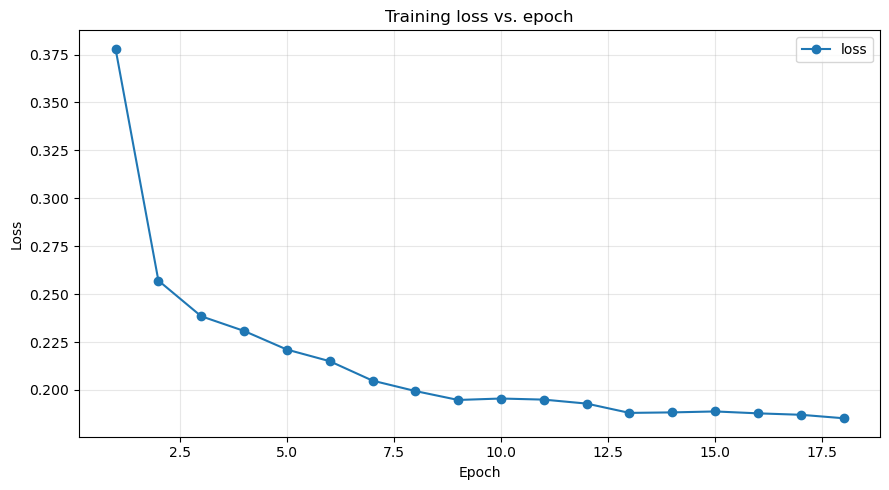

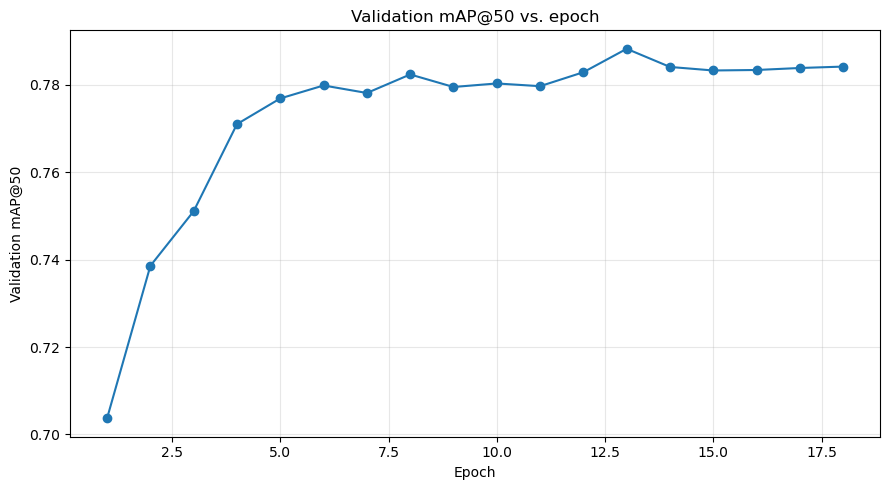

In [15]:
# Plot total loss and each Faster R-CNN loss component by epoch.
epochs_x = [entry["epoch"] for entry in history]
fig, ax = plt.subplots(figsize=(9, 5))
for key in history[0]:
    if key.endswith("loss"):
        ax.plot(epochs_x, [entry[key] for entry in history], marker="o", label=key)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss vs. epoch")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_x, [entry["val_map50"] for entry in history], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation mAP@50")
ax.set_title("Validation mAP@50 vs. epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.2 Performance Analysis (Where is the model underperforming)

In [16]:
# Inspect inference confidence scores before the calibrated cutoff.
@torch.no_grad()
def diagnose_model(model, loader, device, num_batches: int = 5):
    model.eval()
    previous_thresh = model.roi_heads.score_thresh
    model.roi_heads.score_thresh = 0.001
    scores = []
    try:
        for bi, (images, _) in enumerate(loader):
            if bi >= num_batches:
                break
            preds = model([img.to(device) for img in images])
            for pred in preds:
                scores.extend(pred["scores"].detach().cpu().tolist())
    finally:
        model.roi_heads.score_thresh = previous_thresh
    if not scores:
        print("No detections above 0.001 in the inspected batches.")
        return
    score_t = torch.tensor(scores)
    print(f"Collected {len(scores)} detections; score quantiles:")
    for q in (0.0, 0.25, 0.50, 0.75, 0.90, 0.99, 1.0):
        print(f"  q={q:.2f}: {torch.quantile(score_t, q).item():.4f}")

diagnose_model(model, val_loader, DEVICE, num_batches=5)


Collected 1766 detections; score quantiles:
  q=0.00: 0.0010
  q=0.25: 0.0019
  q=0.50: 0.0045
  q=0.75: 0.0242
  q=0.90: 0.1933
  q=0.99: 0.9858
  q=1.00: 0.9985


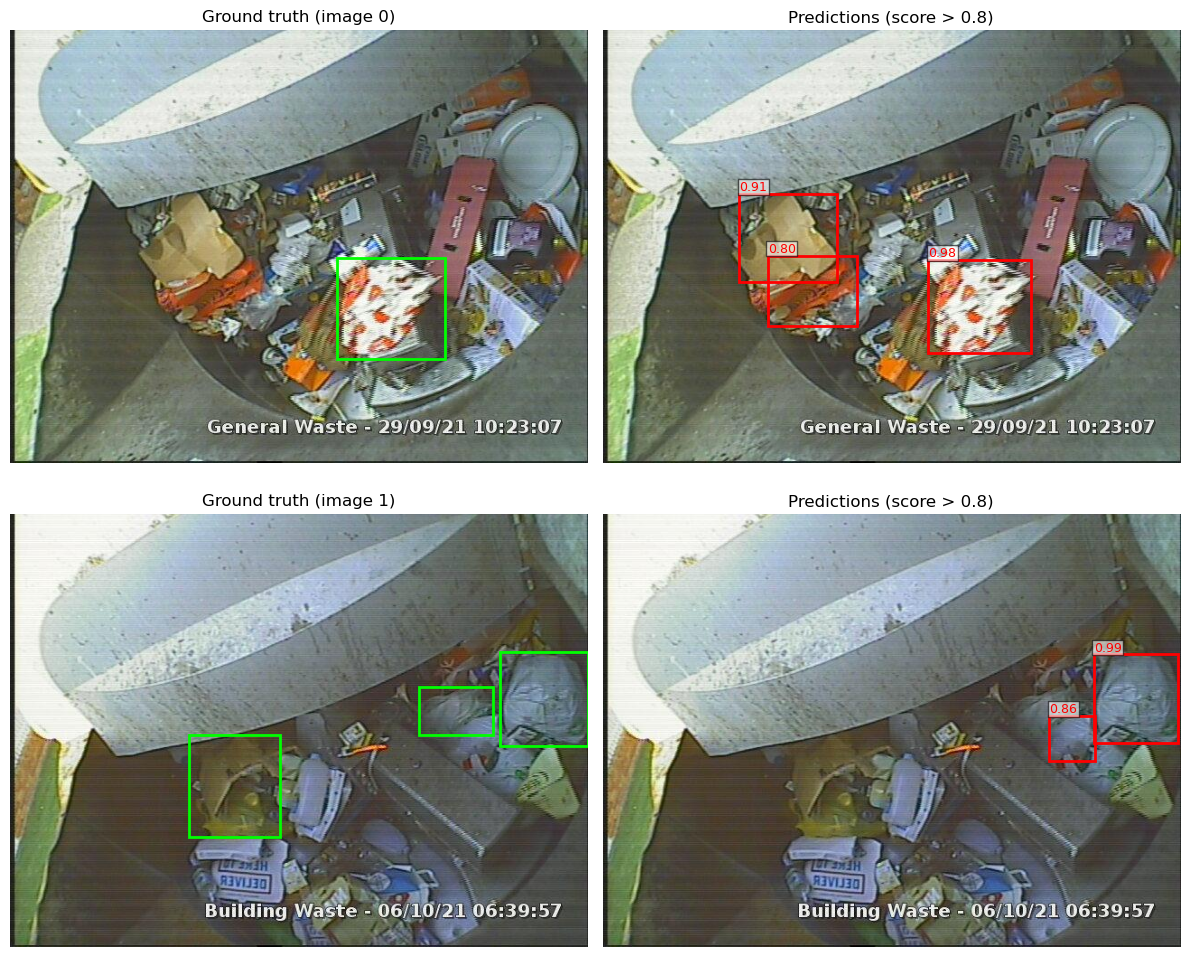

In [17]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_images: int = 4, score_thresh: float = BEST_SCORE_THRESH):
    model.eval()
    idxs = list(range(min(num_images, len(dataset))))
    fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 5 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(idxs):
        img, target = dataset[idx]
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img_np)
        ax_gt.set_title(f"Ground truth (image {idx})")
        ax_gt.axis("off")
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax_gt.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            ))

        # Predictions
        preds = model([img.to(device)])[0]
        ax_pr = axes[row, 1]
        ax_pr.imshow(img_np)
        ax_pr.set_title(f"Predictions (score > {score_thresh})")
        ax_pr.axis("off")
        for box, score in zip(preds["boxes"].cpu(), preds["scores"].cpu()):
            if float(score) < score_thresh:
                continue
            x1, y1, x2, y2 = box.tolist()
            ax_pr.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="red", linewidth=2,
            ))
            ax_pr.text(x1, max(0, y1 - 4), f"{float(score):.2f}",
                       color="red", fontsize=9,
                       bbox=dict(facecolor="white", alpha=0.6, pad=1))

    plt.tight_layout()
    plt.show()


visualize_predictions(model, val_ds, DEVICE, num_images=2, score_thresh=BEST_SCORE_THRESH)

## 5. Test

Speak to a Hackathon Organizer when your team is ready to submit a final model. You will receive two keys to be entered below to download the test dataset and score your model.

### 5.1 Download Test Data

In [18]:
# Insert keys from Hackathon Organizer
AWS_ACCESS_KEY_ID=""
AWS_SECRET_ACCESS_KEY=""

BUCKET = "uprm-hackathon-data"
PREFIX = "2026/test/"            # trailing slash is optional but recommended
DESTINATION = f"{REPO_ROOT}/data/test/"        # local root folder where files will be saved
REGION = "us-east-1"

In [19]:
import os
import boto3
from pathlib import Path

# Download
s3 = boto3.resource('s3',
                    aws_access_key_id=AWS_ACCESS_KEY_ID,
                    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
                    region_name=REGION)

bucket = s3.Bucket(BUCKET)

for obj in bucket.objects.filter(Prefix=PREFIX):
    if obj.key.endswith('/'):  # skip “folder” placeholders
        continue
    rel_path = os.path.relpath(obj.key, PREFIX)
    local_path = Path(DESTINATION) / rel_path
    local_path.parent.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {obj.key} → {local_path}')
    bucket.download_file(obj.key, str(local_path))

ClientError: An error occurred (AuthorizationHeaderMalformed) when calling the ListObjects operation: The authorization header is malformed; a non-empty Access Key (AKID) must be provided in the credential.

### 5.2 Create Test DataLoader

In [ ]:
# Create DataLoader for Test Set
test_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="test")
print(f"test samples: {len(test_ds)}")
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

### 5.3 Grade Model on Test Set

In [ ]:
map50 = evaluate_map50(model, test_loader, DEVICE)
print(f"Test mAP@50 (plastic_bag): {map50:.4f}")

# 6. Grading/Submission Guidelines

## Submissions
Please email your submissions to hamzah.abdulrazzaq@lmco.com. All these items must be complete in order for your submission to be considered for evaluation. 
> 1. Email title set to *yourteamname_submission* 
> 2. The python notebook with all your code (.ipynb) 
> 3. Your model checkpoint (.pt) file
> 4. mAP@50 test score copied in with all the digits

**NOTE**: If your email submission is blocked, please try resending the email with a .allow extension added to the file or email title.

## Evaluation Process
> - The submission deadline is on Sunday (9/27) 12PM.
> - Presentations will take place on Sunday (9/27) 2PM for the top 3 teams highest performing solutions. Teams will provide a walkthrough of their code. A winner shall be announced thereafter.